## 2 卷积和池化层

**2.1 理论计算题**

（1）求输出特征图尺寸：
已知：
- 输入尺寸：$3 \times 32 \times 32$（通道 $C_{in}=3$，高 $H=32$，宽 $W=32$）
- 卷积核数量：$C_{out}=16$
- 卷积核大小：$3 \times 5 \times 5$
- Padding $P=2$，Stride $S=2$

输出高宽公式：
$$
H_{out} = \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1
$$

代入：
$$
H_{out} = \left\lfloor \frac{32 + 4 - 5}{2} \right\rfloor + 1 = \left\lfloor \frac{31}{2} \right\rfloor + 1 = 15 + 1 = 16
$$

同理 $W_{out} = 16$，输出通道数为 $16$。

答案： $16 \times 16 \times 16$

（2）求单个输出通道的一个像素值的乘法次数：

每个输出像素由输入的一个 $3 \times 5 \times 5$ 区域与卷积核逐元素相乘求和。

乘法次数 = 卷积核大小 = $3 \times 5 \times 5 = 75$

答案： $75$

**2.2 编程题**

（1）我做的操作：手动实现了最大池化函数（支持 padding 和 stride），用一个 4×4 的矩阵测试，并将池化前后的结果并排显示为两张热力图，图中标有具体数值。

（2）从输出图中能看到：左边 4×4 的输入矩阵经过 2×2 池化（步幅 2）后，变成右边 2×2 的输出，每个输出值是输入对应 2×2 区域的最大值（如左上角 [1,2,5,6] 变为 6），直观展示了池化如何压缩特征图尺寸并保留最显著特征。

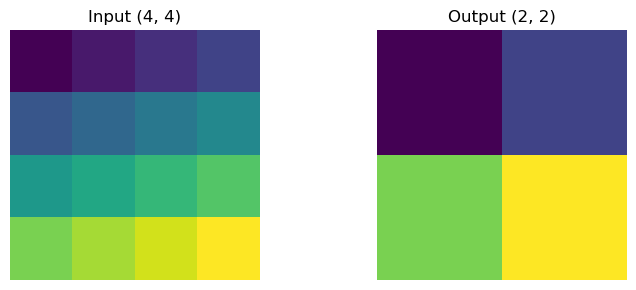

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def max_pool2d_manual(x, kernel_size, stride=1, padding=0):
    if x.ndim == 2:
        x = x[np.newaxis, :, :]
    
    C, H, W = x.shape
    K = kernel_size
    S = stride
    P = padding
    
    x_padded = np.pad(x, ((0, 0), (P, P), (P, P)), mode='constant', constant_values=0)
    
    H_out = (H + 2 * P - K) // S + 1
    W_out = (W + 2 * P - K) // S + 1
    
    out = np.zeros((C, H_out, W_out))
    
    for c in range(C):
        for i in range(H_out):
            for j in range(W_out):
                h_start = i * S
                h_end = h_start + K
                w_start = j * S
                w_end = w_start + K
                region = x_padded[c, h_start:h_end, w_start:w_end]
                out[c, i, j] = np.max(region)
    
    return out.squeeze()


test_img = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])

pooled = max_pool2d_manual(test_img, kernel_size=2, stride=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.imshow(test_img, cmap='viridis')
ax1.set_title(f'Input {test_img.shape}')
ax1.axis('off')
ax2.imshow(pooled, cmap='viridis')
ax2.set_title(f'Output {pooled.shape}')
ax2.axis('off')
plt.tight_layout()
plt.show()

## 3 LeNet, AlexNet, VGG 和 NiN

**3.1 理论计算题**

（1）求一个 $5 \times 5$ 卷积层参数量：

输入通道 $C$，输出通道 $C$，卷积核大小 $C \times 5 \times 5$

参数量 = $C \times C \times 5 \times 5 = 25C^2$

答案： $25C^2$

（2）求两个串联的 $3 \times 3$ 卷积层总参数量：

每层参数量 = $C \times C \times 3 \times 3 = 9C^2$

两层总参数量 = $9C^2 + 9C^2 = 18C^2$

答案： $18C^2$

**3.2 编程题**

做了什么操作： 定义了一个 NiNBlock 类，继承自 nn.Module。在初始化函数中，用 nn.Sequential 依次堆叠了三个卷积层：第一个是普通卷积层（卷积核大小、步幅、填充由参数传入），将输入通道数转换为输出通道数；第二个是 1×1 卷积层，保持通道数不变；第三个也是 1×1 卷积层，保持通道数不变。每个卷积层后面紧跟一个 ReLU 激活函数。在前向传播中，输入 x 依次经过这三个卷积和激活，输出结果。测试时创建了一个输入通道为 3、输出通道为 96、卷积核 5×5、步幅 1、填充 2 的 NiN 块，输入一个 1×3×32×32 的随机张量，打印了输入和输出形状。

In [2]:
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(NiNBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU()
        )
    
    def forward(self, x):
        return self.block(x)


# 测试
nin_block = NiNBlock(3, 96, 5, 1, 2)
x = torch.randn(1, 3, 32, 32)
y = nin_block(x)
print(f"输入形状: {x.shape}")
print(f"输出形状: {y.shape}")

输入形状: torch.Size([1, 3, 32, 32])
输出形状: torch.Size([1, 96, 32, 32])


## 4 Inception, 批量归一化和残差网络

**4.1 理论计算题**

已知：
- $x = [2, 4, 6, 8]$
- $\gamma = 2$，$\beta = 1$，$\epsilon = 0$

均值：
$$
\mu = \frac{2+4+6+8}{4} = 5
$$

方差：
$$
\sigma^2 = \frac{(2-5)^2 + (4-5)^2 + (6-5)^2 + (8-5)^2}{4} = \frac{9+1+1+9}{4} = 5
$$

标准化：
$$
\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} = \frac{x_i - 5}{\sqrt{5}}
$$

缩放平移：
$$
y_i = \gamma \hat{x}_i + \beta
$$

计算结果：
- $\hat{x}_1 = \frac{-3}{\sqrt{5}} \approx -1.3416$，$y_1 = 2 \times (-1.3416) + 1 \approx -1.6832$
- $\hat{x}_2 = \frac{-1}{\sqrt{5}} \approx -0.4472$，$y_2 \approx 0.1056$
- $\hat{x}_3 = \frac{1}{\sqrt{5}} \approx 0.4472$，$y_3 \approx 1.8944$
- $\hat{x}_4 = \frac{3}{\sqrt{5}} \approx 1.3416$，$y_4 \approx 3.6832$

答案： $y \approx [-1.6832,\ 0.1056,\ 1.8944,\ 3.6832]$

**4.2 编程题**

做了什么操作： 定义了一个 ResidualBlock 类，继承自 nn.Module。在初始化函数中，定义了两个相同的 3×3 卷积层，每个卷积层后跟一个 BatchNorm2d 层，再用一个 ReLU 放在第一个 BN 之后（第二个 BN 之后不加激活，等残差相加后再加）。如果 use_1x1conv 为 True，则额外定义一个 1×1 卷积层用于调整跳跃连接的通道数。在前向传播中，先保存输入 x 作为 identity，然后依次经过 conv1、bn1、relu、conv2、bn2 得到 out。如果 use_1x1conv 为 True，则 identity 经过 1×1 卷积调整；否则 identity 保持不变。最后 out 和 identity 相加，再经过一个 ReLU 输出。测试时创建了 use_1x1conv=True 的残差块，输入通道 32、输出通道 64，输入形状为 1×32×32×32 的张量，打印了输入和输出形状。

In [3]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.use_1x1conv = use_1x1conv
        if use_1x1conv:
            self.conv_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.use_1x1conv:
            identity = self.conv_shortcut(x)

        out += identity
        out = self.relu(out)
        return out


# 测试
block = ResidualBlock(32, 64, use_1x1conv=True)
x = torch.randn(1, 32, 32, 32)
y = block(x)
print(f"输入: {x.shape} -> 输出: {y.shape}")

输入: torch.Size([1, 32, 32, 32]) -> 输出: torch.Size([1, 64, 32, 32])


## 5 图像增广，微调和样式迁移

**5.1 理论计算题**

（1）为什么底层学习率小，顶层学习率大？

底层特征提取器在源数据集（如 ImageNet）上已经学到了通用特征（边缘、纹理、形状等），这些特征对大多数视觉任务都有用，因此应保持稳定，避免被破坏，所以使用较小的学习率甚至冻结。

顶层（输出层）需要适应新的目标任务，通常是随机初始化的，因此需要较大的学习率来快速学习目标数据集中的特定特征。

（2）目标数据集小且与源数据集相似时的微调策略：

- 冻结大部分底层特征提取层
- 只微调最后的全连接层（或最后几层）
- 使用较小的学习率（例如 $10^{-4}$ 或更小）
- 加强数据增广以防止过拟合
- 使用早停法（early stopping）
- 若仍过拟合，可加 Dropout 或权重衰减

**5.2 编程题**

（1）我做的操作：用 torchvision 构建了一个增广管道（随机裁剪缩放、随机水平翻转、随机颜色调整），对一张随机生成的彩色图像进行处理，并排显示原图和 3 次不同的增广结果。

（2）从输出图能看到： 四张图各不相同——原图是一个随机彩色方块，三个增广结果在内容区域、左右朝向、颜色深浅上都有差异（裁剪导致内容不同、翻转导致镜像、颜色抖动导致色调变化），展示了同一张图片如何通过随机变换生成多样化的训练样本。

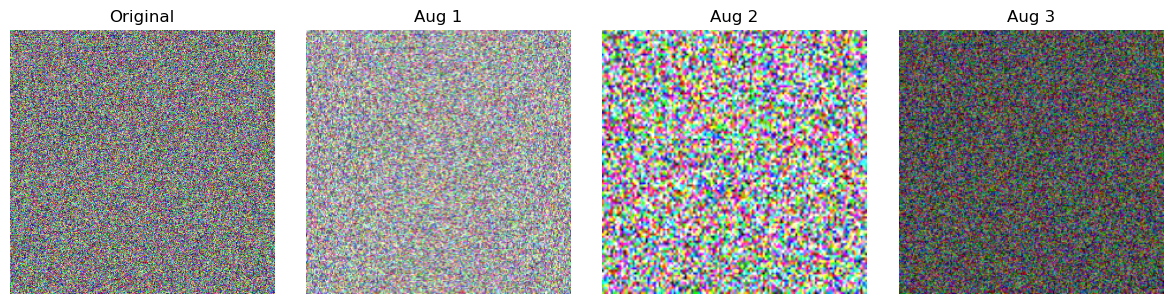

In [7]:
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

augmentation_pipeline = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.ToTensor()
])

# 创建简单测试图
img = Image.fromarray((np.random.rand(300, 300, 3) * 255).astype('uint8'))

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(3):
    aug_img = augmentation_pipeline(img).permute(1, 2, 0).numpy()
    axes[i+1].imshow(aug_img)
    axes[i+1].set_title(f'Aug {i+1}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

## 6 目标检测，计算机视觉训练技巧

**6.1 理论计算题**

已知：
- 真实框 $A = [10, 10, 50, 50]$
- 预测框 $B = [30, 30, 70, 70]$

交集坐标：
$$
x_1 = \max(10, 30) = 30,\quad y_1 = \max(10, 30) = 30
$$
$$
x_2 = \min(50, 70) = 50,\quad y_2 = \min(50, 70) = 50
$$

交集面积：
$$
\text{intersection} = (50-30) \times (50-30) = 20 \times 20 = 400
$$

A 面积：
$$
(50-10) \times (50-10) = 40 \times 40 = 1600
$$

B 面积：
$$
(70-30) \times (70-30) = 40 \times 40 = 1600
$$

并集面积：
$$
\text{union} = 1600 + 1600 - 400 = 2800
$$

IoU：
$$
\text{IoU} = \frac{400}{2800} = \frac{1}{7} \approx 0.142857
$$

答案： $\dfrac{1}{7}$

**6.2 编程题**

做了什么操作： 定义了一个 label_smoothing_cross_entropy 函数。函数接收预测值 pred、真实标签 target、平滑因子 epsilon 和类别数 num_classes。首先对 pred 计算 log_softmax 得到 log_probs。然后创建一个形状与 log_probs 相同的全零张量 smooth_label，将所有位置填充为 epsilon/(num_classes-1)，再用 scatter_ 方法将真实标签对应位置的值改为 1-epsilon。最后计算 -smooth_label * log_probs，对类别维度求和取平均得到损失。测试时创建了一个 5 分类的预测张量（第一个类别的 logit 很高为 10，其他为 0.1），真实标签为第 0 类，分别计算了标准交叉熵损失和 epsilon=0.1 的标签平滑损失，打印了两个损失的数值进行对比。

In [5]:
import torch
import torch.nn.functional as F

def label_smoothing_cross_entropy(pred, target, epsilon=0.1, num_classes=None):
    if num_classes is None:
        num_classes = pred.size(-1)
    log_probs = F.log_softmax(pred, dim=-1)
    
    smooth_label = torch.full_like(log_probs, epsilon / (num_classes - 1))
    smooth_label.scatter_(1, target.unsqueeze(1), 1 - epsilon)
    
    loss = (-smooth_label * log_probs).sum(dim=-1).mean()
    return loss


# 测试对比
pred = torch.tensor([[10.0, 0.1, 0.1, 0.1, 0.1]])  # 5分类
target = torch.tensor([0])

ce_loss = F.cross_entropy(pred, target)
ls_loss = label_smoothing_cross_entropy(pred, target, epsilon=0.1)

print(f"标准交叉熵损失: {ce_loss.item():.4f}")
print(f"标签平滑损失 (ε=0.1): {ls_loss.item():.4f}")

标准交叉熵损失: 0.0002
标签平滑损失 (ε=0.1): 0.9902
